In [1]:
from pathlib import Path

import diffrax
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import yaml
from scipy import stats

from environments.harmonic_oscillator import HarmonicOscillator
from environments.duffing_oscillator import DuffingOscillator
from evaluators.ode_evaluator import ODEEvaluator
from evaluators.sde_evaluator import SDEEvaluator
from utils import *

# import matplotlib.font_manager as fm
# fm.fontManager.addfont('/content/drive/MyDrive/SDE-GP/src/TimesNewRoman.ttf')

plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['font.family'] = "serif"


def distance_reward(x, target):
    return -((x[0] - target[0]) ** 2 + x[1] ** 2)

These device(s) are detected: [CpuDevice(id=0)]


## Helper functions

In [2]:
def collect_training_fitness(results_dir):
    results_dir = Path(results_dir)
    results = []
    for subfolder in results_dir.iterdir():
        fitness_file = subfolder / "best_fitnesses.npy"
        if fitness_file.exists():
            fitness = np.load(fitness_file)
            results.append(fitness)
    return results

def compare_fitness(x, y, name_x="GP-SDE", name_y="GP-ODE"):
    stat, p = stats.ttest_ind(x, y, equal_var=False, alternative="greater")

    df = pd.DataFrame({
        "Method":  [name_x, name_y],
        "Fitness": [f"{np.mean(x):.4f} ± {np.std(x, ddof=1):.4f}",
                    f"{np.mean(y):.4f} ± {np.std(y, ddof=1):.4f}"],
        "Median":  [np.median(x), np.median(y)],
        "p-value": [p, ""],
    })
    return df


def plot_fitness(gpode_train, gpsde_train, gpode_test, gpsde_test):
    fig = plt.figure(figsize=(6.0, 2.0), dpi=150)
    outer = gridspec.GridSpec(
        1, 2,
        figure=fig,
        width_ratios=[2.0, 1.0],
        wspace=0.30,
        left=0.05,
        right=0.97,
        top=0.90,
        bottom=0.12
    )

    ax_train_static = fig.add_subplot(outer[0])
    ax_test_static = fig.add_subplot(outer[1])

    # (a) training fitness
    ode = -np.array(gpode_train)
    sde = -np.array(gpsde_train)
    gens = np.arange(1, ode.shape[1] + 1)

    ode_mean, ode_std = jnp.mean(ode, axis=0), jnp.std(ode, axis=0)
    sde_mean, sde_std = jnp.mean(sde, axis=0), jnp.std(sde, axis=0)

    ax_train_static.plot(gens, ode_mean, lw=2, color="#ff7f0e", label="GP-ODE")
    ax_train_static.fill_between(
        gens,
        ode_mean - ode_std,
        ode_mean + ode_std,
        alpha=0.25,
        color="#ff7f0e"
    )

    ax_train_static.plot(gens, sde_mean, lw=2, color="#2ca02c", label="GP-SDE")
    ax_train_static.fill_between(
        gens,
        sde_mean - sde_std,
        sde_mean + sde_std,
        alpha=0.25,
        color="#2ca02c"
    )

    ax_train_static.set_title("Training fitness", fontsize=12)
    ax_train_static.set_xlabel("Generation", fontsize=12)
    ax_train_static.set_ylabel("Fitness", fontsize=12)
    ax_train_static.tick_params(labelsize=12)
    ax_train_static.legend(frameon=False, fontsize=12)
    ax_train_static.spines[["right", "top"]].set_visible(False)

    # (b) validation fitness boxplot
    ode_s = np.asarray(gpode_test)
    sde_s = np.asarray(gpsde_test)

    bp = ax_test_static.boxplot(
        [ode_s, sde_s],
        patch_artist=True,
        widths=0.6,
        showfliers=True,
        tick_labels=["GP-ODE", "GP-SDE"],
        flierprops=dict(
            marker='.',
            markerfacecolor='black',
            markeredgecolor='black',
            alpha=0.8
        )
    )

    colors = ["#ff7f0e", "#2ca02c"]

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    ax_test_static.set_title("Validation fitness", fontsize=12)
    ax_test_static.set_ylabel("Fitness", fontsize=12)
    ax_test_static.tick_params(labelsize=12)
    ax_test_static.spines[["right", "top"]].set_visible(False)

    plt.show()

In [3]:
def plot_trajectory(program, env_name, n_obs, feedback_fn, lambd=0.0, jump_size=0.0, gamma=0.0, candidate_path=None, plot_idx=None, seed=10):

    candidate = jnp.load(candidate_path, allow_pickle=True)
    env, strategy, fitness_fn = setup(program, env_name, n_obs, feedback_fn, gamma=gamma)
    test_data = get_data(jr.PRNGKey(seed), env, 16, 0.1, 50, lambd, jump_size)
    ts, xs, ys, us, activities, targets, fbs, rpes, fitness, diffusion_coefs = validate(program, strategy, fitness_fn, candidate, test_data)

    ts, xs, ys, us, activities, targets, fbs, rpes, fitness, diffusion_coefs = map(
        np.asarray,
        (ts, xs, ys, us, activities, targets, fbs, rpes, fitness, diffusion_coefs),
    )

    if plot_idx is not None:
        best = plot_idx
    else:
        best = int(np.argmin(fitness))
    print(f"Best trajectory index: {best}")

    if program == "GP-SDE":
        fig = plt.figure(figsize=(7.0, 4.5), dpi=150)
        gs = gridspec.GridSpec(
            3, 2, hspace=0.75, wspace=0.28,
            left=0.10, right=0.97, top=0.92, bottom=0.10,
            height_ratios=[1, 1, 0.75],
        )

        ax_state = fig.add_subplot(gs[0, :])
        ax_ctrl = fig.add_subplot(gs[1, 0])
        ax_mem = fig.add_subplot(gs[1, 1])
        ax_fb = fig.add_subplot(gs[2, 0])
        ax_sig = fig.add_subplot(gs[2, 1])
    else:
        fig = plt.figure(figsize=(7.0, 3.2), dpi=150)
        gs = gridspec.GridSpec(2, 3, hspace=0.75, wspace=0.35, left=0.08, right=0.97, top=0.91, bottom=0.13, height_ratios=[1, 1])

        ax_state = fig.add_subplot(gs[0, :])
        ax_ctrl = fig.add_subplot(gs[1, 0])
        ax_mem = fig.add_subplot(gs[1, 1])
        ax_fb = fig.add_subplot(gs[1, 2])
        ax_sig = None

    # (a) state tracking
    ax_state.plot(ts, ys[best, :, 0], c="#1f77b4", alpha=0.3, lw=1.0)
    if n_obs > 1:
        ax_state.plot(ts, ys[best, :, 1], c="#ff7f0e", alpha=0.3, lw=1.0)
    ax_state.plot(ts, xs[best, :, 0], c="#1f77b4", lw=1.4, label=r"$x_0$")
    ax_state.plot(ts, xs[best, :, 1], c="#ff7f0e", lw=1.4, label=r"$x_1$")
    ax_state.plot(ts, targets[best], c="k", ls="--", lw=1.4, label=r"$x_0^{*}$")
    ax_state.set_title("State tracking", fontsize=11)
    ax_state.set_xlabel("Time (s)", fontsize=9)
    ax_state.tick_params(labelsize=8)
    ax_state.legend(frameon=False, loc="lower right", handlelength=1.2, fontsize=8)

    # (b) control input
    ax_ctrl.plot(ts, us[best], c="#2ca02c", lw=1.4, label="$u$")
    ax_ctrl.set_title("Control input", fontsize=11)
    ax_ctrl.set_xlabel("Time (s)", fontsize=9)
    ax_ctrl.tick_params(labelsize=8)

    # (c) memory activity
    ax_mem.plot(ts, activities[best, :, 0], c="#9467bd", lw=1.4, label=r"$a_0$")
    ax_mem.plot(ts, activities[best, :, 1], c="#8c564b", lw=1.4, label=r"$a_1$")
    ax_mem.set_title("Memory activity", fontsize=11)
    ax_mem.set_xlabel("Time (s)", fontsize=9)
    ax_mem.tick_params(labelsize=8)
    ax_mem.legend(frameon=False, loc="best", handlelength=1.2, fontsize=8)

    # (d) feedback signal
    ax_fb.plot(ts, fbs[best].squeeze(), c="#d62728", lw=1.4, label="true reward")
    ax_fb.plot(ts, rpes[best].squeeze(), c="#ff7f0e", lw=1.4, label="RPE")
    ax_fb.set_title("Instantaneous reward", fontsize=11)
    ax_fb.set_xlabel("Time (s)", fontsize=9)
    ax_fb.tick_params(labelsize=8)
    ax_fb.legend(frameon=False, loc="best", handlelength=1.2, fontsize=8)

    # (e) diffusion coefficients
    if ax_sig is not None:
        ax_sig.plot(ts, diffusion_coefs[best, :, 0], c="#0000ff", lw=1.4, label=r"$g_0$")
        ax_sig.plot(ts, diffusion_coefs[best, :, 1], c="#ff7f0e", lw=1.0, label=r"$g_1$")
        ax_sig.set_title("Memory diffusion", fontsize=11)
        ax_sig.set_xlabel("Time (s)", fontsize=9)
        ax_sig.tick_params(labelsize=8)
        ax_sig.legend(frameon=False, loc="lower right", handlelength=1.2, fontsize=8)

    # panel labels
    panels = [ax_state, ax_ctrl, ax_mem, ax_fb]
    if ax_sig is not None:
        panels.append(ax_sig)
    for ax, letter in zip(panels, "abcde"):
        ax.text(-0.08, 1.12, f"({letter})", transform=ax.transAxes, fontsize=11, fontweight="bold")

    plt.show()

# HO - Full observability

### Static target

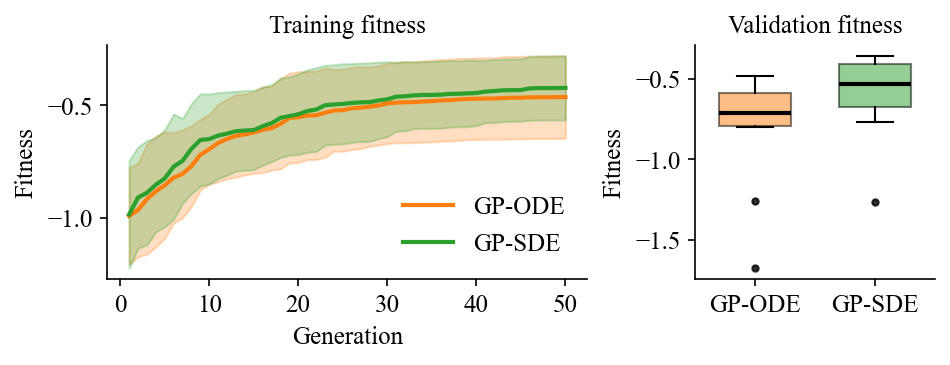

In [5]:
ode_train = collect_training_fitness("../results/HO/Experiment_H1/GP-ODE")
sde_train = collect_training_fitness("../results/HO/Experiment_H1/GP-SDE")
ode_test = np.load("../results/HO/Experiment_H1/GP-ODE/val_fitnesses.npy")
sde_test = np.load("../results/HO/Experiment_H1/GP-SDE/val_fitnesses.npy")

plot_fitness(ode_train, sde_train, ode_test, sde_test)

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Best trajectory index: 13


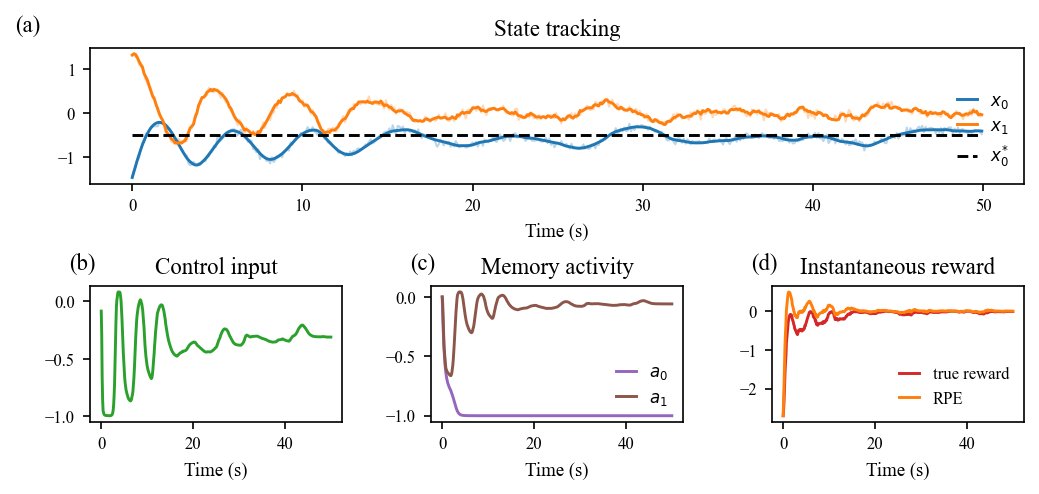

In [6]:
plot_trajectory(
    "GP-ODE",
    "HO",
    n_obs=2,
    feedback_fn=distance_reward,
    lambd=0.0,
    jump_size=0.0,
    gamma=0.0,
    candidate_path="../results/HO/Experiment_H1/GP-ODE/seed_3/best_candidate.npy",
    plot_idx=13,
    seed=9999
)

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Best trajectory index: 13


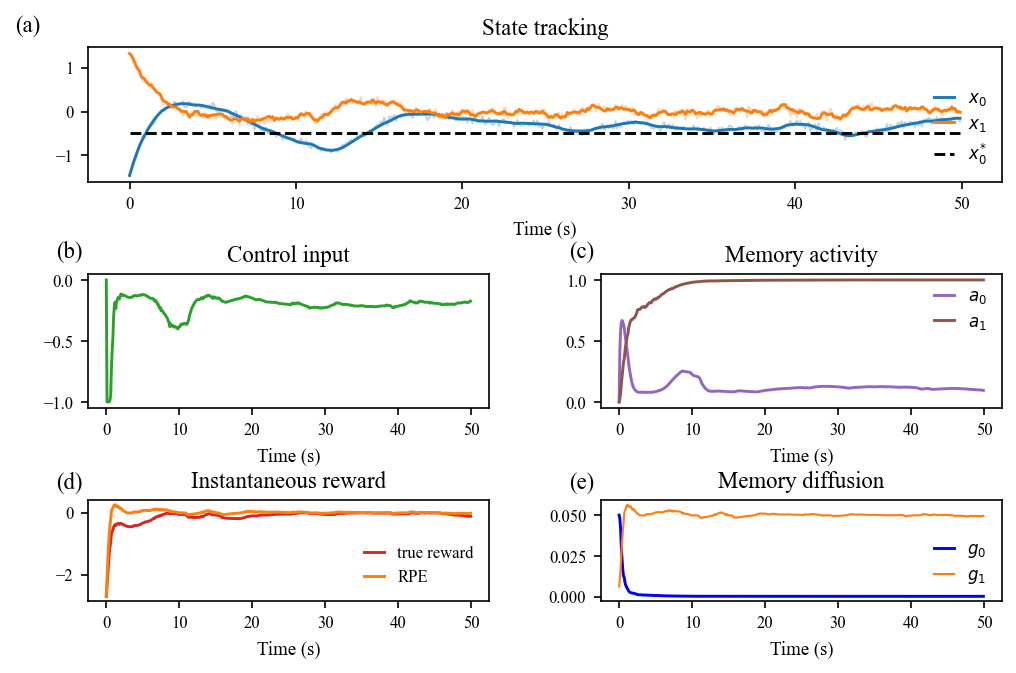

In [7]:
plot_trajectory(
    "GP-SDE",
    "HO",
    n_obs=2,
    feedback_fn=distance_reward,
    lambd=0.0,
    jump_size=0.0,
    gamma=0.1,
    candidate_path="../results/HO/Experiment_H1/GP-SDE/seed_3/best_candidate.npy",
    plot_idx=13,
    seed=9999
)

### Dynamic target

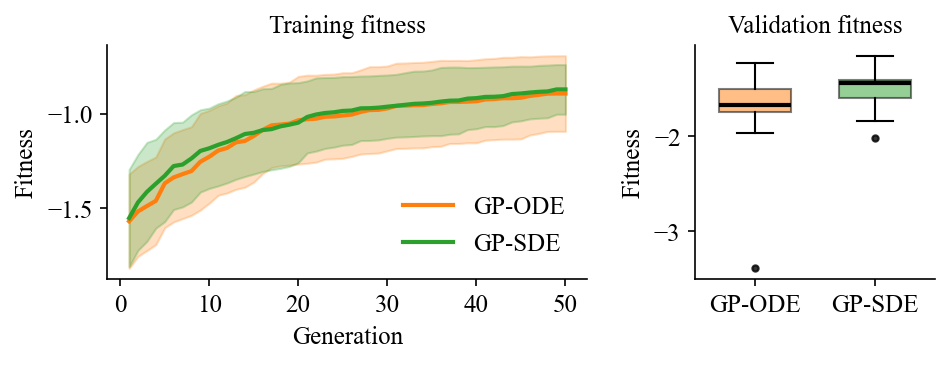

In [8]:
ode_train = collect_training_fitness("../results/HO/Experiment_H2/GP-ODE")
sde_train = collect_training_fitness("../results/HO/Experiment_H2/GP-SDE")
ode_test = np.load("../results/HO/Experiment_H2/GP-ODE/val_fitnesses.npy")
sde_test = np.load("../results/HO/Experiment_H2/GP-SDE/val_fitnesses.npy")

plot_fitness(ode_train, sde_train, ode_test, sde_test)

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Best trajectory index: 0


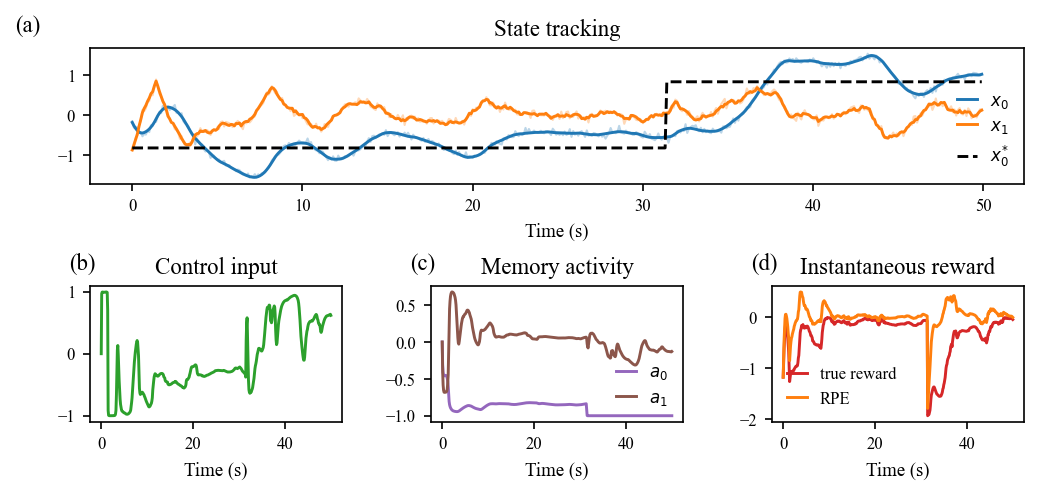

In [9]:
plot_trajectory(
    "GP-ODE",
    "HO",
    n_obs=2,
    feedback_fn=distance_reward,
    lambd=0.05,
    jump_size=1.0,
    gamma=0.0,
    candidate_path="../results/HO/Experiment_H2/GP-ODE/seed_4/best_candidate.npy",
    plot_idx=0,
    seed=12345
)

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Best trajectory index: 0


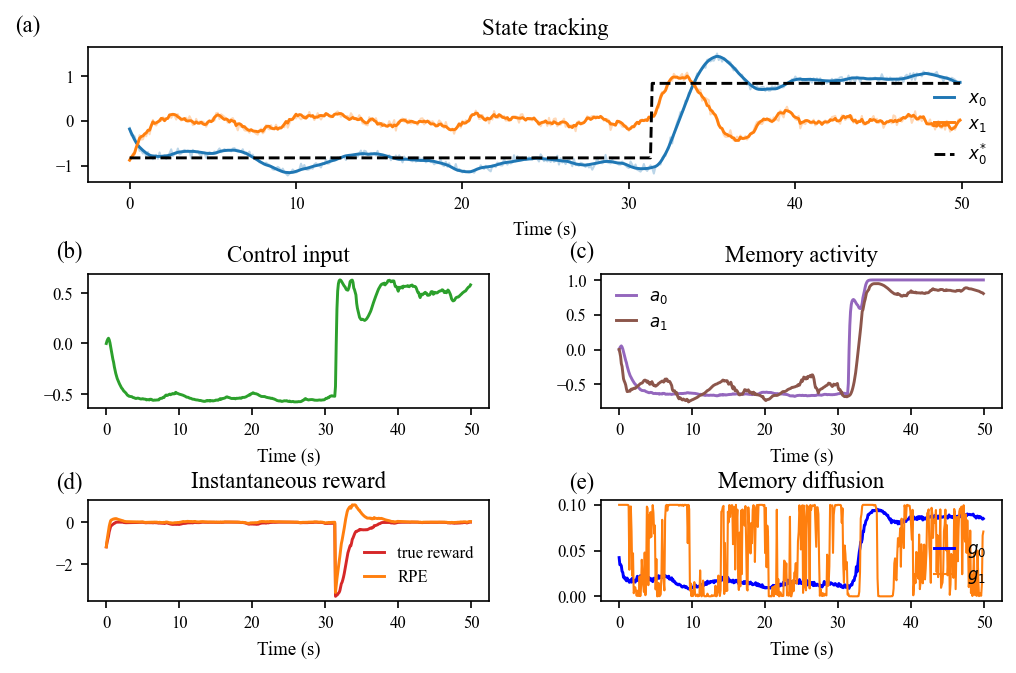

In [10]:
plot_trajectory(
    "GP-SDE",
    "HO",
    n_obs=2,
    feedback_fn=distance_reward,
    lambd=0.05,
    jump_size=1.0,
    gamma=0.1,
    candidate_path="../results/HO/Experiment_H2/GP-SDE/seed_6/best_candidate.npy",
    plot_idx=0,
    seed=12345
)

# HO - Partial observability

### Static target

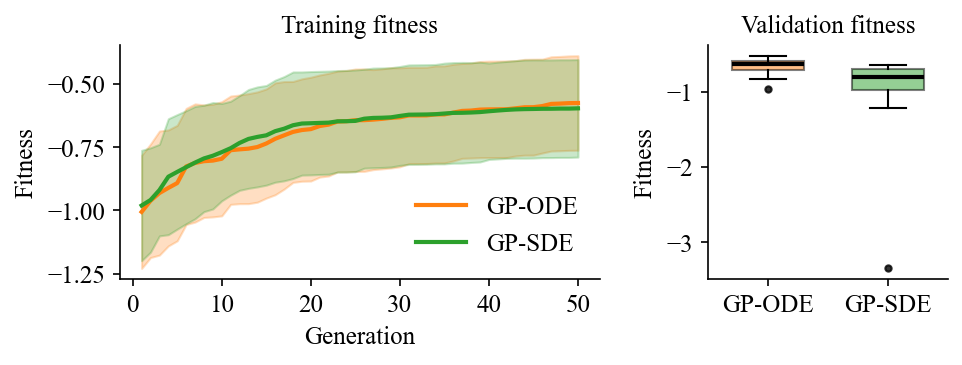

In [11]:
ode_train = collect_training_fitness("../results/HO/Experiment_H3/GP-ODE")
sde_train = collect_training_fitness("../results/HO/Experiment_H3/GP-SDE")
ode_test = np.load("../results/HO/Experiment_H3/GP-ODE/val_fitnesses.npy")
sde_test = np.load("../results/HO/Experiment_H3/GP-SDE/val_fitnesses.npy")

plot_fitness(ode_train, sde_train, ode_test, sde_test)

Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Best trajectory index: 13


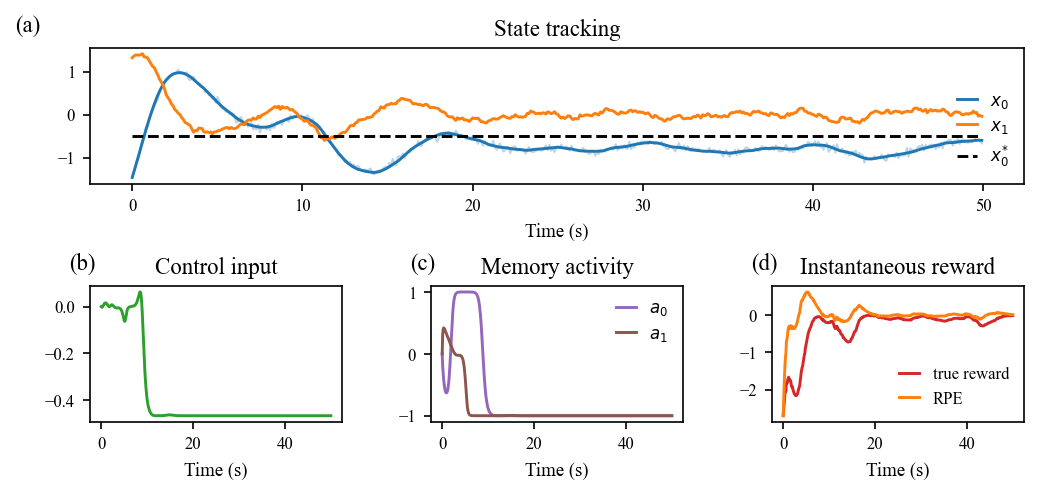

In [12]:
plot_trajectory(
    "GP-ODE",
    "HO",
    n_obs=1,
    feedback_fn=distance_reward,
    lambd=0.0,
    jump_size=0.0,
    gamma=0.0,
    candidate_path="../results/HO/Experiment_H3/GP-ODE/seed_8/best_candidate.npy",
    plot_idx=13,
    seed=9999
)

Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Best trajectory index: 13


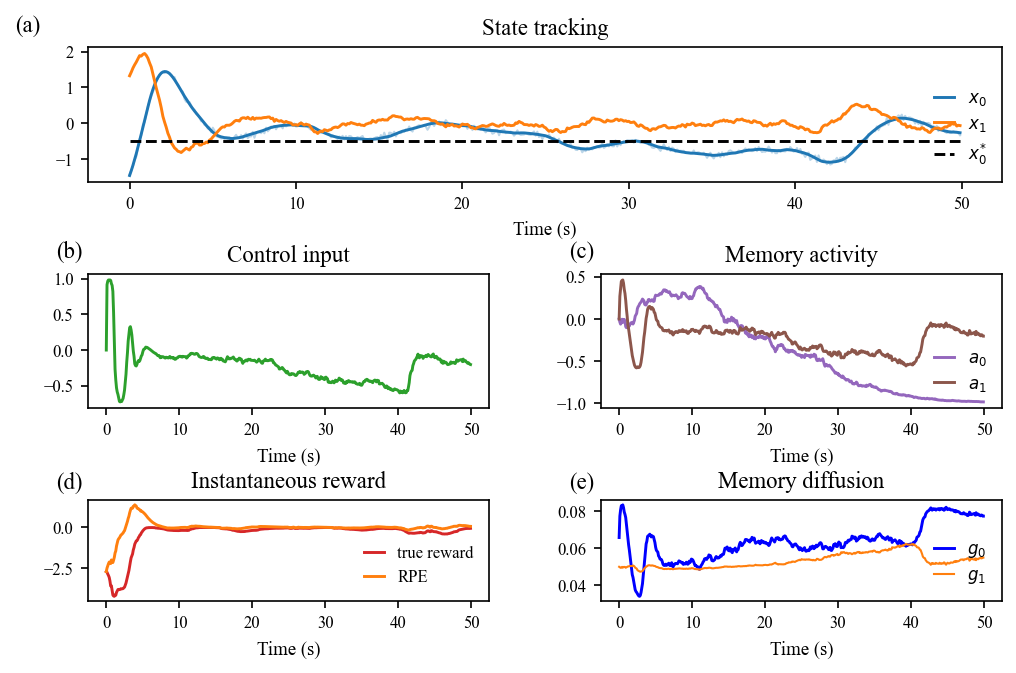

In [13]:
plot_trajectory(
    "GP-SDE",
    "HO",
    n_obs=1,
    feedback_fn=distance_reward,
    lambd=0.0,
    jump_size=0.0,
    gamma=0.1,
    candidate_path="../results/HO/Experiment_H3/GP-SDE/seed_3/best_candidate.npy",
    plot_idx=13,
    seed=9999
)

### Dynamic target

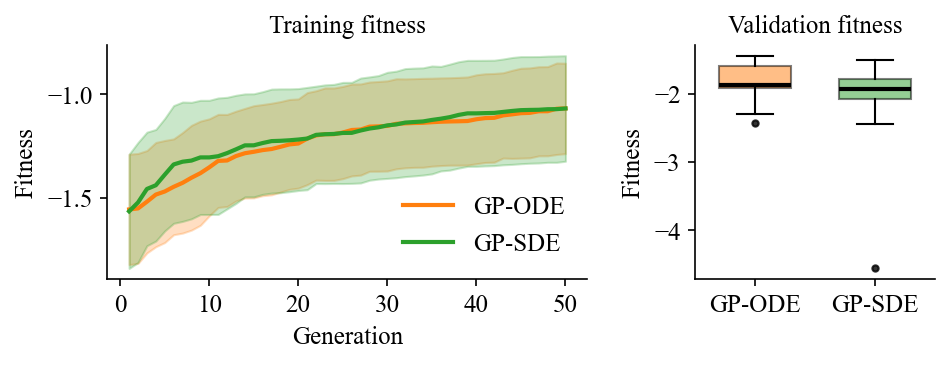

In [14]:
ode_train = collect_training_fitness("../results/HO/Experiment_H4/GP-ODE")
sde_train = collect_training_fitness("../results/HO/Experiment_H4/GP-SDE")
ode_test = np.load("../results/HO/Experiment_H4/GP-ODE/val_fitnesses.npy")
sde_test = np.load("../results/HO/Experiment_H4/GP-SDE/val_fitnesses.npy")

plot_fitness(ode_train, sde_train, ode_test, sde_test)

Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Best trajectory index: 0


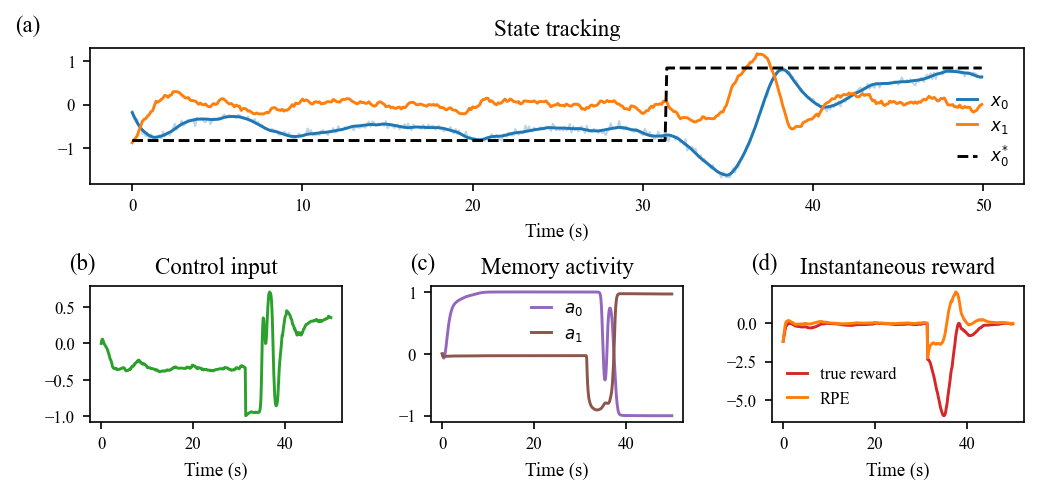

In [15]:
plot_trajectory(
    "GP-ODE",
    "HO",
    n_obs=1,
    feedback_fn=distance_reward,
    lambd=0.05,
    jump_size=1.0,
    gamma=0.1,
    candidate_path="../results/HO/Experiment_H4/GP-ODE/seed_2/best_candidate.npy",
    plot_idx=0,
    seed=12345
)

Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Best trajectory index: 0


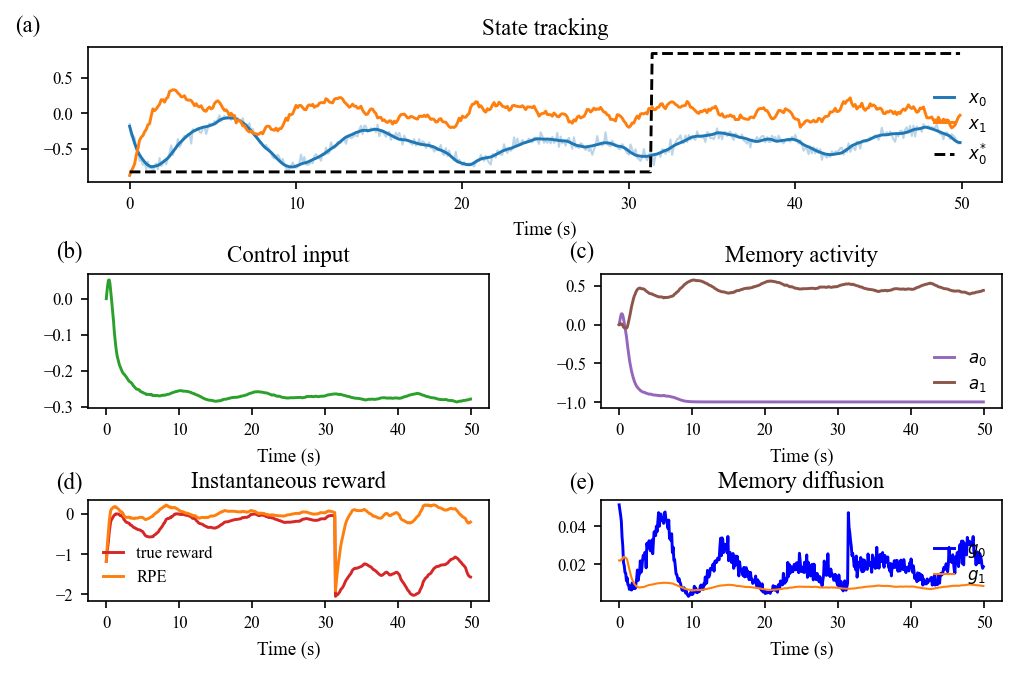

In [16]:
plot_trajectory(
    "GP-SDE",
    "HO",
    n_obs=1,
    feedback_fn=distance_reward,
    lambd=0.05,
    jump_size=1.0,
    gamma=0.1,
    candidate_path="../results/HO/Experiment_H4/GP-SDE/seed_6/best_candidate.npy",
    plot_idx=0,
    seed=12345
)

# DO - Full observability

### Static target

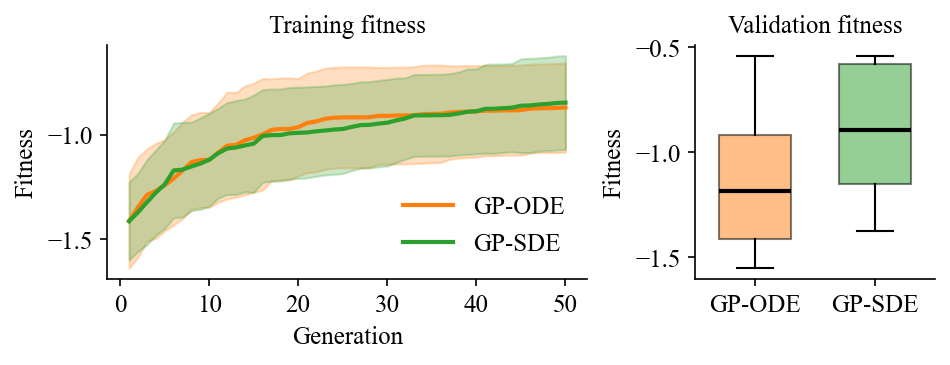

In [17]:
ode_train = collect_training_fitness("../results/DO/Experiment_D1/GP-ODE")
sde_train = collect_training_fitness("../results/DO/Experiment_D1/GP-SDE")
ode_test = np.load("../results/DO/Experiment_D1/GP-ODE/val_fitnesses.npy")
sde_test = np.load("../results/DO/Experiment_D1/GP-SDE/val_fitnesses.npy")

plot_fitness(ode_train, sde_train, ode_test, sde_test)

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Best trajectory index: 14


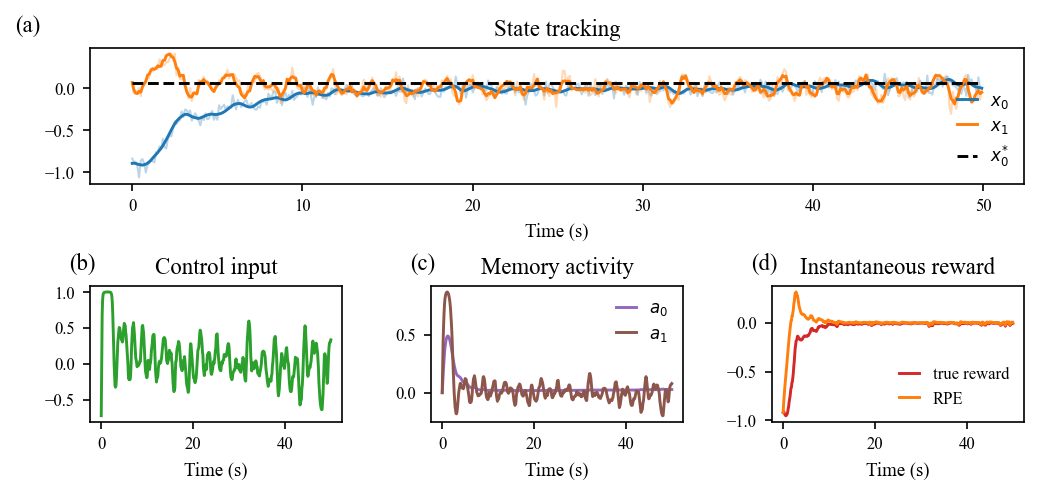

In [18]:
plot_trajectory(
    "GP-ODE",
    "DO",
    n_obs=2,
    feedback_fn=distance_reward,
    lambd=0.0,
    jump_size=0.0,
    gamma=0.0,
    candidate_path="../results/DO/Experiment_D1/GP-ODE/seed_8/best_candidate.npy",
    plot_idx=14,
    seed=999
)

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Best trajectory index: 14


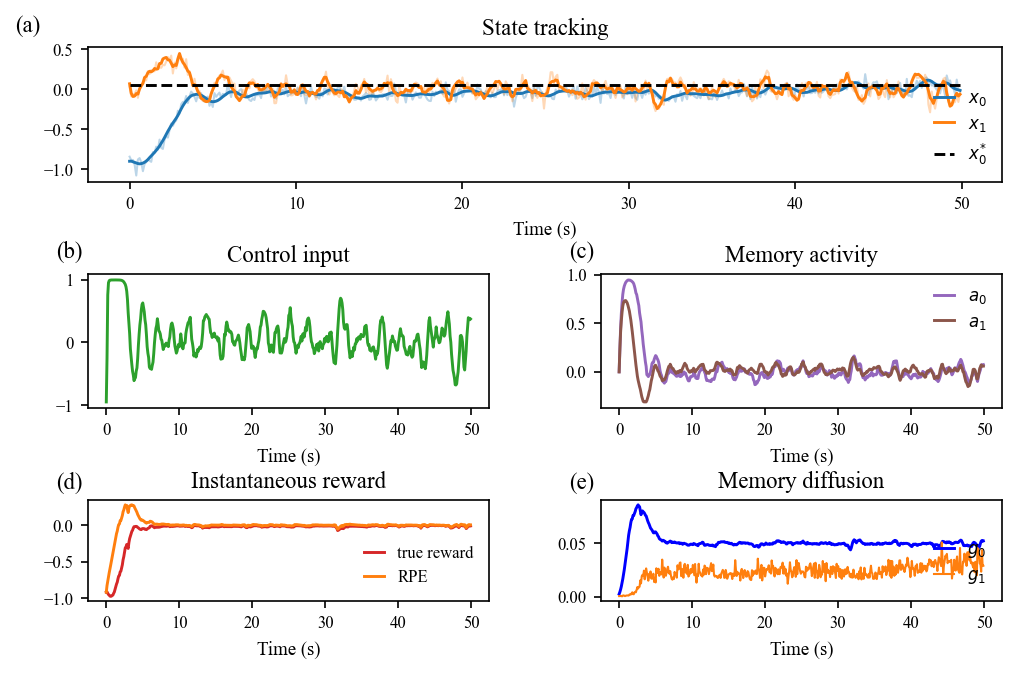

In [19]:
plot_trajectory(
    "GP-SDE",
    "DO",
    n_obs=2,
    feedback_fn=distance_reward,
    lambd=0.0,
    jump_size=0.0,
    gamma=0.1,
    candidate_path="../results/DO/Experiment_D1/GP-SDE/seed_8/best_candidate.npy",
    plot_idx=14,
    seed=999
)

### Dynamic target

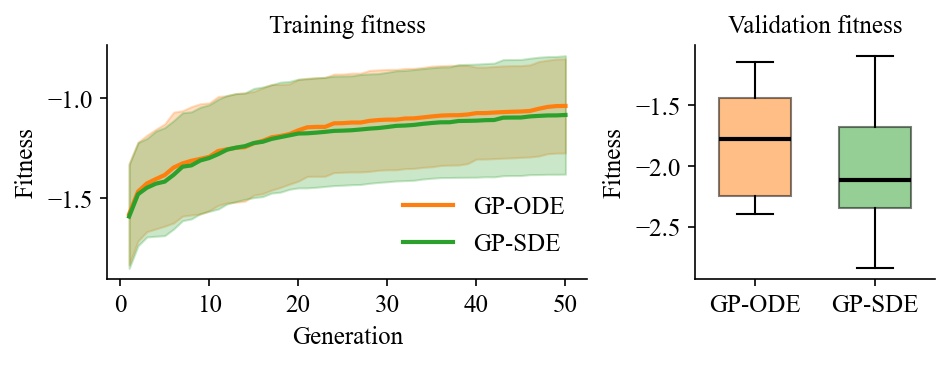

In [82]:
ode_train = collect_training_fitness("../results/DO/Experiment_D2/GP-ODE")
sde_train = collect_training_fitness("../results/DO/Experiment_D2/GP-SDE")
ode_test = np.load("../results/DO/Experiment_D2/GP-ODE/val_fitnesses.npy")
sde_test = np.load("../results/DO/Experiment_D2/GP-SDE/val_fitnesses.npy")

plot_fitness(ode_train, sde_train, ode_test, sde_test)

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Best trajectory index: 15


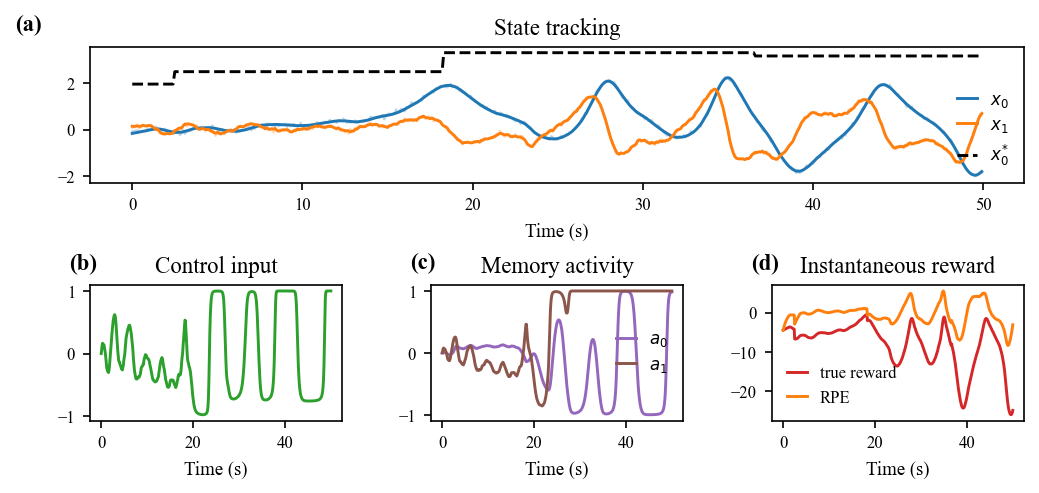

In [11]:
plot_trajectory(
    "GP-ODE",
    "DO",
    n_obs=2,
    feedback_fn=distance_reward,
    lambd=0.05,
    jump_size=1.0,
    gamma=0.0,
    candidate_path="../results/DO/Experiment_D2/GP-ODE/seed_6/best_candidate.npy",
    plot_idx=15,
    seed=9999
)

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Best trajectory index: 15


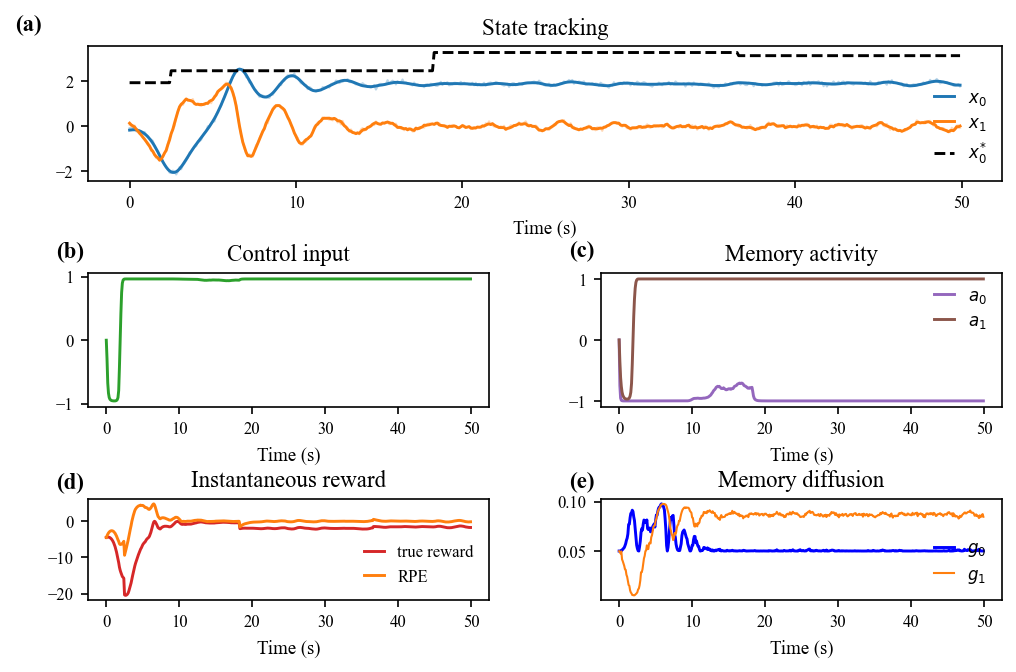

In [12]:
plot_trajectory(
    "GP-SDE",
    "DO",
    n_obs=2,
    feedback_fn=distance_reward,
    lambd=0.05,
    jump_size=1.0,
    gamma=0.1,
    candidate_path="../results/DO/Experiment_D2/GP-SDE/seed_6/best_candidate.npy",
    plot_idx=15,
    seed=9999
)

# DO - Partial observability

### Static target

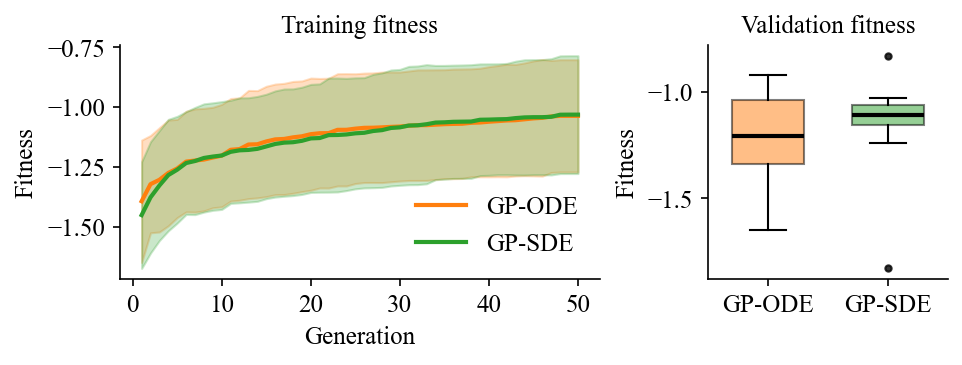

In [20]:
ode_train = collect_training_fitness("../results/DO/Experiment_D3/GP-ODE")
sde_train = collect_training_fitness("../results/DO/Experiment_D3/GP-SDE")
ode_test = np.load("../results/DO/Experiment_D3/GP-ODE/val_fitnesses.npy")
sde_test = np.load("../results/DO/Experiment_D3/GP-SDE/val_fitnesses.npy")

plot_fitness(ode_train, sde_train, ode_test, sde_test)

Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Best trajectory index: 14


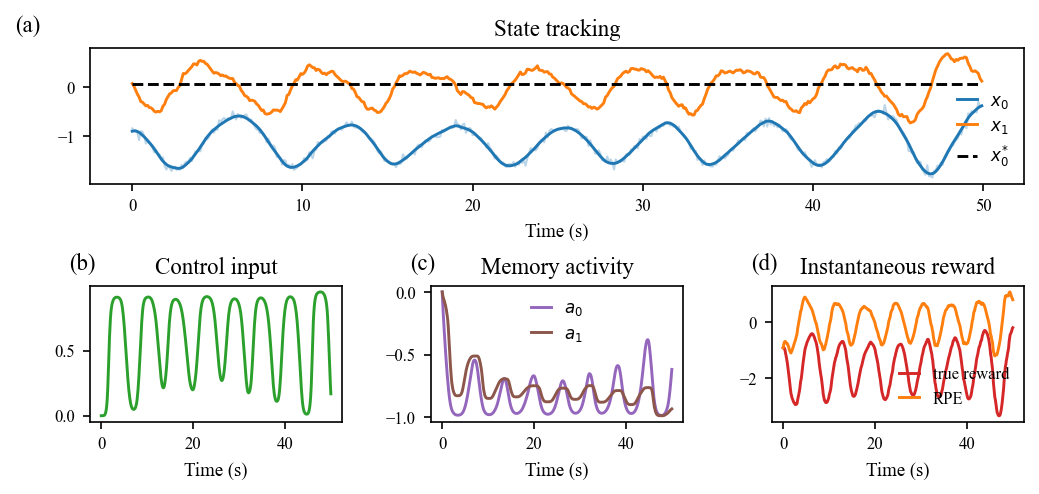

In [21]:
plot_trajectory(
    "GP-ODE",
    "DO",
    n_obs=1,
    feedback_fn=distance_reward,
    lambd=0.0,
    jump_size=0.0,
    gamma=0.0,
    candidate_path="../results/DO/Experiment_D3/GP-ODE/seed_6/best_candidate.npy",
    plot_idx=14,
    seed=999
)

Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Best trajectory index: 14


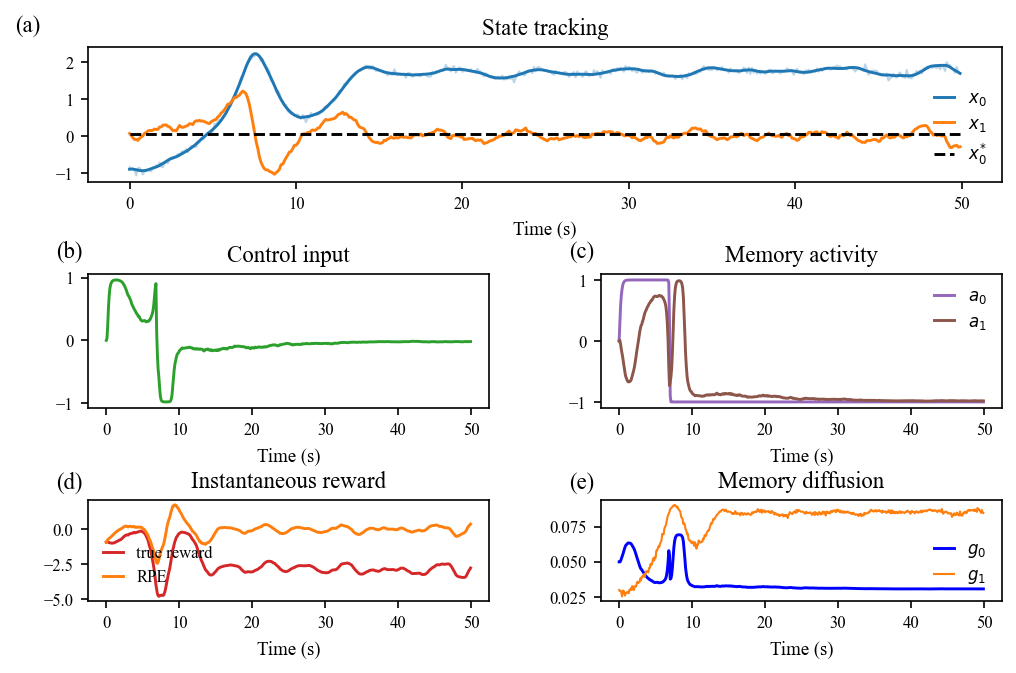

In [22]:
plot_trajectory(
    "GP-SDE",
    "DO",
    n_obs=1,
    feedback_fn=distance_reward,
    lambd=0.0,
    jump_size=0.0,
    gamma=0.1,
    candidate_path="../results/DO/Experiment_D3/GP-SDE/seed_6/best_candidate.npy",
    plot_idx=14,
    seed=999
)

### Dynamic target

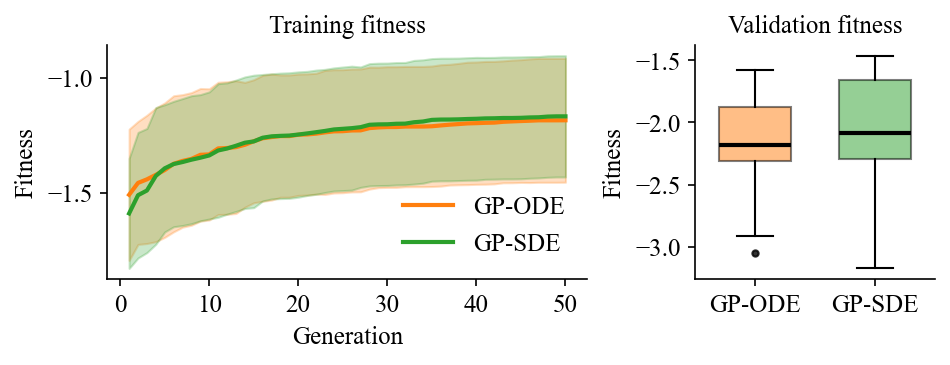

In [ ]:
ode_train = collect_training_fitness("../results/DO/Experiment_D4/GP-ODE")
sde_train = collect_training_fitness("../results/DO/Experiment_D4/GP-SDE")
ode_test = np.load("../results/DO/Experiment_D4/GP-ODE/val_fitnesses.npy")
sde_test = np.load("../results/DO/Experiment_D4/GP-SDE/val_fitnesses.npy")

plot_fitness(ode_train, sde_train, ode_test, sde_test)

Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Best trajectory index: 15


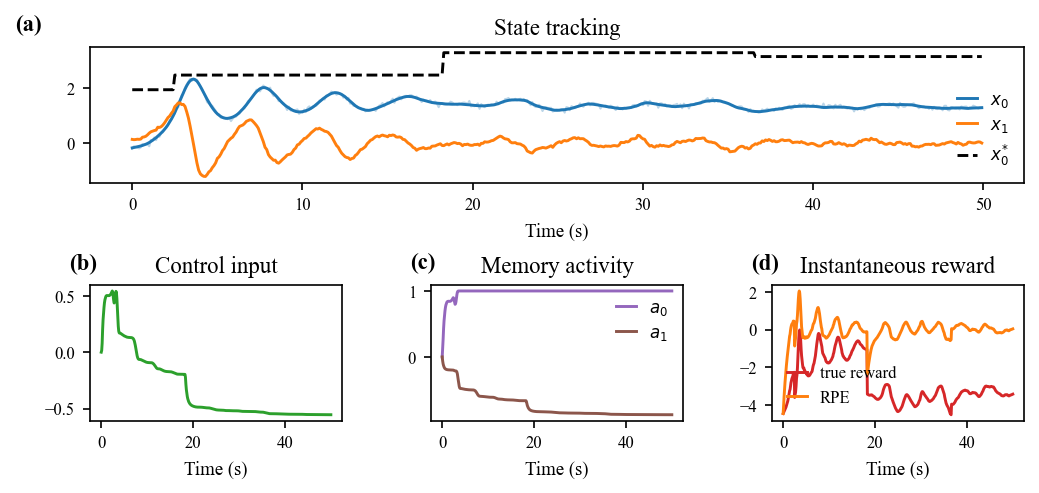

In [9]:
plot_trajectory(
    "GP-ODE",
    "DO",
    n_obs=1,
    feedback_fn=distance_reward,
    lambd=0.05,
    jump_size=1.0,
    gamma=0.0,
    candidate_path="../results/DO/Experiment_D4/GP-ODE/seed_6/best_candidate.npy",
    plot_idx=15,
    seed=9999
)

Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Best trajectory index: 15


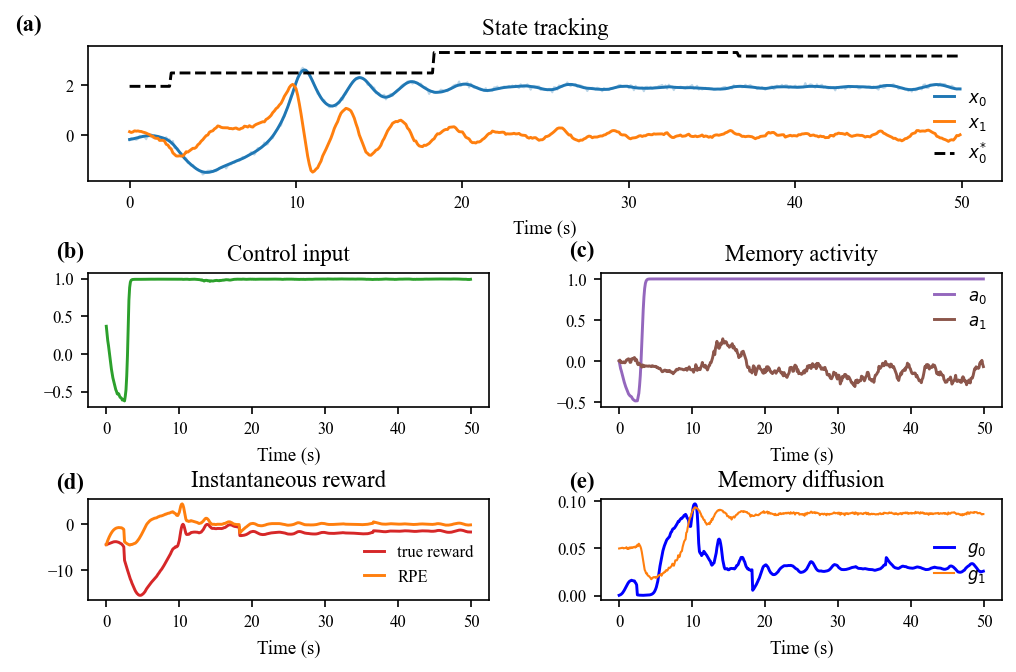

In [10]:
plot_trajectory(
    "GP-SDE",
    "DO",
    n_obs=1,
    feedback_fn=distance_reward,
    lambd=0.05,
    jump_size=1.0,
    gamma=0.1,
    candidate_path="../results/DO/Experiment_D4/GP-SDE/seed_6/best_candidate.npy",
    plot_idx=15,
    seed=9999
)

# Noise ablation study

In [ ]:
def noise_ablation(results_dir, env_name, n_obs, feedback_fn, gamma,
                   process_noise=0.1, obs_noise=0.05, lambd=0.0, jump_size=0.0,
                   batch_size=16, dt=0.1, T=50.0, seed=10):
    results_dir = Path(results_dir)
    fitness_on, fitness_off = [], []

    for subfolder in sorted(results_dir.iterdir()):
        candidate_path = subfolder / "best_candidate.npy"
        if not candidate_path.exists():
            continue
        candidate = jnp.load(candidate_path, allow_pickle=True)

        env, strategy, fitness_fn = setup("GP-SDE", env_name, n_obs, feedback_fn, process_noise=process_noise, obs_noise=obs_noise, gamma=gamma)
        test_data = get_data(jr.PRNGKey(seed), env, batch_size, dt, T, lambd, jump_size)
        fitness_noise_on = validate("GP-SDE", strategy, fitness_fn, candidate, test_data)[-2]
        fitness_noise_on = float(jnp.mean(-fitness_noise_on))

        env, strategy, fitness_fn = setup("GP-SDE", env_name, n_obs, feedback_fn, process_noise=process_noise, obs_noise=obs_noise, gamma=0.0)
        test_data = get_data(jr.PRNGKey(seed), env, batch_size, dt, T, lambd, jump_size)
        fitness_noise_off = validate("GP-SDE", strategy, fitness_fn, candidate, test_data)[-2]
        fitness_noise_off = float(jnp.mean(-fitness_noise_off))

        fitness_on.append(fitness_noise_on)
        fitness_off.append(fitness_noise_off)

    return np.array(fitness_on), np.array(fitness_off)


def plot_noise_ablation(results_dict):
    conditions = list(results_dict.keys())

    fig, ax = plt.subplots(figsize=(1.2 * len(conditions), 2.0), dpi=150)
    for i, cond in enumerate(conditions):
        on, off = results_dict[cond]["on"], results_dict[cond]["off"]
        x_on, x_off = i * 1.5, i * 1.5 + 0.8
        for s in range(len(on)):
            ax.plot([x_on, x_off], [on[s], off[s]], color="gray", alpha=0.3, lw=0.8, zorder=1)

        ax.scatter(np.full(len(on), x_on), on, color="#2ca02c", s=25, zorder=2, edgecolors="white", linewidths=0.5)
        ax.scatter(np.full(len(off), x_off), off, color="#d62728", s=25, zorder=2, edgecolors="white", linewidths=0.5)

    ax.set_xticks([i * 1.5 + 0.4 for i in range(len(conditions))])
    ax.set_xticklabels(conditions, fontsize=10)
    ax.set_ylabel("Fitness", fontsize=11)
    ax.spines[["right", "top"]].set_visible(False)

    ax.legend(handles=[
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markersize=7, label='Noise on'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=7, label='Noise off'),
    ], frameon=False, fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

    plt.show()

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 

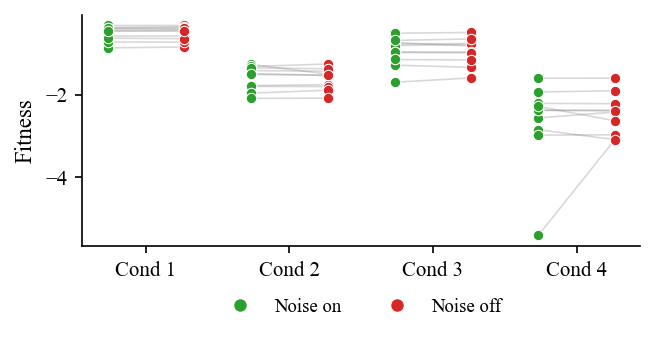

In [ ]:
# Harmonic oscillator task
on_h1, off_h1 = noise_ablation("../results/HO/Experiment_H1/GP-SDE/", "HO", 2, distance_reward, gamma=0.1, lambd=0.0, jump_size=0.0, seed=9999)
on_h2, off_h2 = noise_ablation("../results/HO/Experiment_H2/GP-SDE/", "HO", 2, distance_reward, gamma=0.1, lambd=0.05, jump_size=1.0, seed=9999)
on_h3, off_h3 = noise_ablation("../results/HO/Experiment_H3/GP-SDE/", "HO", 1, distance_reward, gamma=0.1, lambd=0.0, jump_size=0.0, seed=9999)
on_h4, off_h4 = noise_ablation("../results/HO/Experiment_H4/GP-SDE/", "HO", 1, distance_reward, gamma=0.1, lambd=0.05, jump_size=1.0, seed=9999)

# Plot
results_dict = {
    "Cond 1": {"on": on_h1, "off": off_h1},
    "Cond 2": {"on": on_h2, "off": off_h2},
    "Cond 3": {"on": on_h3, "off": off_h3},
    "Cond 4": {"on": on_h4, "off": off_h4},
}
plot_noise_ablation(results_dict)

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 

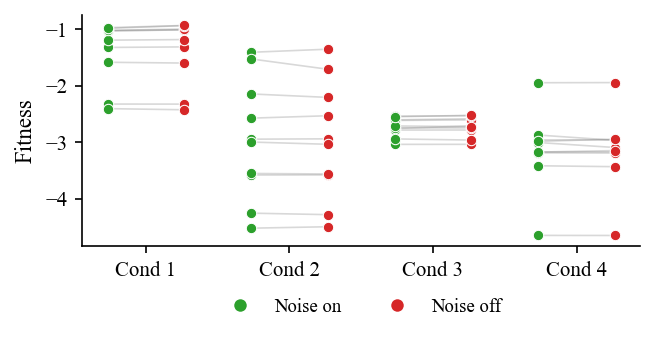

In [ ]:
# Duffing oscillator task
on_h1, off_h1 = noise_ablation("../results/DO/Experiment_D1/GP-SDE/", "DO", 2, distance_reward, gamma=0.1, lambd=0.0, jump_size=0.0, seed=9999)
on_h2, off_h2 = noise_ablation("../results/DO/Experiment_D2/GP-SDE/", "DO", 2, distance_reward, gamma=0.1, lambd=0.05, jump_size=1.0, seed=9999)
on_h3, off_h3 = noise_ablation("../results/DO/Experiment_D3/GP-SDE/", "DO", 1, distance_reward, gamma=0.1, lambd=0.0, jump_size=0.0, seed=9999)
on_h4, off_h4 = noise_ablation("../results/DO/Experiment_D4/GP-SDE/", "DO", 1, distance_reward, gamma=0.1, lambd=0.05, jump_size=1.0, seed=9999)

# Plot
results_dict = {
    "Cond 1": {"on": on_h1, "off": off_h1},
    "Cond 2": {"on": on_h2, "off": off_h2},
    "Cond 3": {"on": on_h3, "off": off_h3},
    "Cond 4": {"on": on_h4, "off": off_h4},
}
plot_noise_ablation(results_dict)

In [ ]:
def plot_noise_on_off(ax_state, ax_mem, env_name, n_obs, feedback_fn, gamma, candidate_path,
                            lambd=0.0, jump_size=0.0, plot_idx=None, seed=10, title=None):
    program = "GP-SDE"
    candidate = jnp.load(candidate_path, allow_pickle=True)

    env, strategy, fitness_fn = setup(program, env_name, n_obs, feedback_fn, gamma=gamma)
    test_data = get_data(jr.PRNGKey(seed), env, 16, 0.1, 50, lambd, jump_size)

    ts_on, xs_on, ys_on, us_on, activities_on, targets_on, fbs_on, rpes_on, fitness_on, diffusion_coefs_on = validate(
        program, strategy, fitness_fn, candidate, test_data)

    ts_on, xs_on, ys_on, us_on, activities_on, targets_on, fbs_on, rpes_on, fitness_on, diffusion_coefs_on = map(
        np.asarray,
        (ts_on, xs_on, ys_on, us_on, activities_on, targets_on, fbs_on, rpes_on, fitness_on, diffusion_coefs_on),
    )

    env, strategy, fitness_fn = setup(program, env_name, n_obs, feedback_fn, gamma=0.0)
    test_data = get_data(jr.PRNGKey(seed), env, 16, 0.1, 50, lambd, jump_size)

    ts_off, xs_off, ys_off, us_off, activities_off, targets_off, fbs_off, rpes_off, fitness_off, diffusion_coefs_off = validate(
        program, strategy, fitness_fn, candidate, test_data)

    ts_off, xs_off, ys_off, us_off, activities_off, targets_off, fbs_off, rpes_off, fitness_off, diffusion_coefs_off = map(
        np.asarray,
        (ts_off, xs_off, ys_off, us_off, activities_off, targets_off, fbs_off, rpes_off, fitness_off, diffusion_coefs_off),
    )

    best_on = plot_idx if plot_idx is not None else int(np.argmin(fitness_on))
    best_off = plot_idx if plot_idx is not None else int(np.argmin(fitness_off))

    ax_state.plot(ts_on, xs_on[best_on, :, 0], c="#1f77b4", lw=1.2, label=r"$x_0$")
    ax_state.plot(ts_off, xs_off[best_off, :, 0], c="#1f77b4", lw=1.2, ls="--", alpha=0.6)
    ax_state.plot(ts_on, targets_on[best_on].squeeze(), c="k", ls=":", lw=1.2, label=r"$x_0^*$")

    ax_mem.plot(ts_on, activities_on[best_on, :, 0], c="#9467bd", lw=1.2, label=r"$a_0$")
    ax_mem.plot(ts_on, activities_on[best_on, :, 1], c="#8c564b", lw=1.2, label=r"$a_1$")
    ax_mem.plot(ts_off, activities_off[best_off, :, 0], c="#9467bd", lw=1.2, ls="--", alpha=0.6)
    ax_mem.plot(ts_off, activities_off[best_off, :, 1], c="#8c564b", lw=1.2, ls="--", alpha=0.6)

    ax_state.set_title("State tracking", fontsize=11)
    ax_mem.set_title("Memory activity", fontsize=11)

    return ax_state.get_legend_handles_labels(), ax_mem.get_legend_handles_labels()

Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'y1', 'a0', 'a1', 'rpe'].


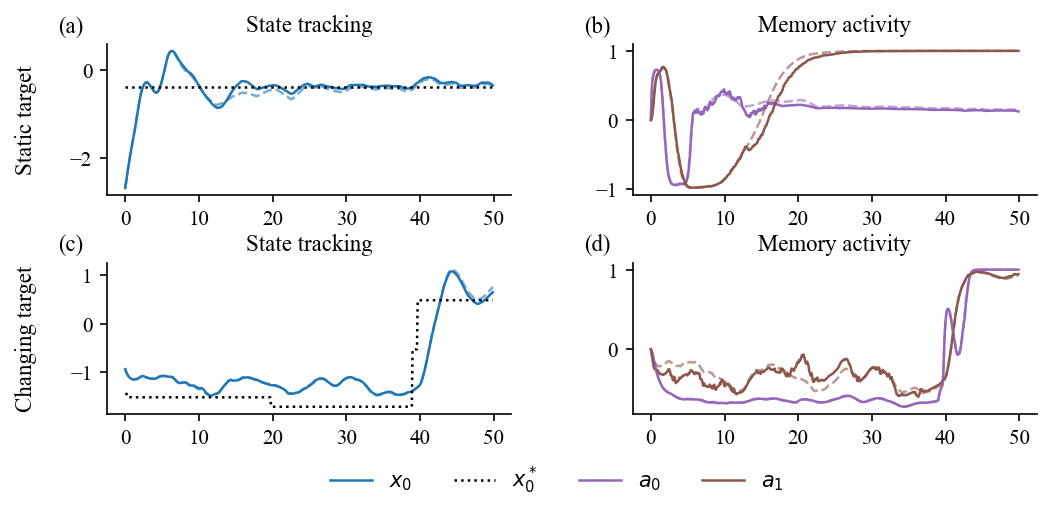

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8.0, 3.2), dpi=150, gridspec_kw={"hspace": 0.45, "wspace": 0.30})

(hs1, ls1), (hm1, lm1) = plot_noise_on_off(
    axs[0, 0], axs[0, 1],
    "HO", 2, distance_reward,
    gamma=0.1,
    candidate_path="../results/HO/Experiment_H1/GP-SDE/seed_3/best_candidate.npy",
    lambd=0.0,
    jump_size=0.0,
    plot_idx=1,
    seed=9999,
)

plot_noise_on_off(
    axs[1, 0], axs[1, 1],
    "HO", 2, distance_reward,
    gamma=0.1,
    candidate_path="../results/HO/Experiment_H2/GP-SDE/seed_6/best_candidate.npy",
    lambd=0.05,
    jump_size=1.0,
    plot_idx=13,
    seed=9999,
)

axs[0, 0].text(-0.2, 0.5, "Static target", transform=axs[0, 0].transAxes, rotation=90, va="center", ha="center", fontsize=11)
axs[1, 0].text(-0.2, 0.5, "Changing target", transform=axs[1, 0].transAxes, rotation=90, va="center", ha="center", fontsize=11)

for ax, letter in zip(axs.flatten(), ["a", "b", "c", "d"]):
    ax.text(-0.12, 1.08, f"({letter})", transform=ax.transAxes, fontsize=11)
    ax.spines[["right", "top"]].set_visible(False)

fig.legend(hs1 + hm1, ls1 + lm1, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.1))

plt.show()

Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].
Input data should be formatted as: ['y0', 'a0', 'a1', 'rpe'].


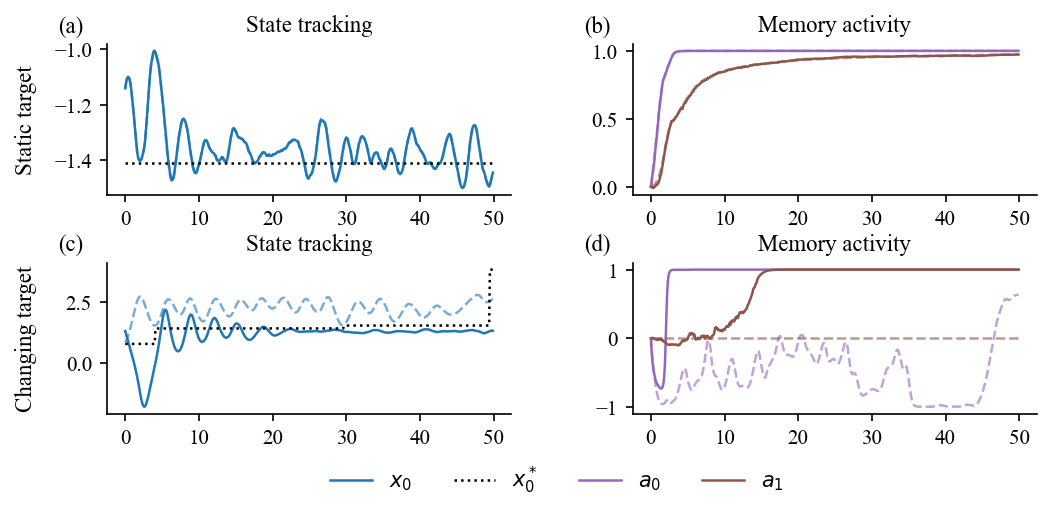

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8.0, 3.2), dpi=150, gridspec_kw={"hspace": 0.45, "wspace": 0.30})

(hs1, ls1), (hm1, lm1) = plot_noise_on_off(
    axs[0, 0], axs[0, 1],
    "DO", 1, distance_reward,
    gamma=0.1,
    candidate_path="../results/DO/Experiment_D3/GP-SDE/seed_6/best_candidate.npy",
    lambd=0.0,
    jump_size=0.0,
    seed=1234
)

plot_noise_on_off(
    axs[1, 0], axs[1, 1],
    "DO", 1, distance_reward,
    gamma=0.1,
    candidate_path="../results/DO/Experiment_D4/GP-SDE/seed_6/best_candidate.npy",
    lambd=0.1,
    jump_size=1.0,
    seed=1234
)

axs[0, 0].text(-0.2, 0.5, "Static target", transform=axs[0, 0].transAxes, rotation=90, va="center", ha="center", fontsize=11)
axs[1, 0].text(-0.2, 0.5, "Changing target", transform=axs[1, 0].transAxes, rotation=90, va="center", ha="center", fontsize=11)

for ax, letter in zip(axs.flatten(), ["a", "b", "c", "d"]):
    ax.text(-0.12, 1.08, f"({letter})", transform=ax.transAxes, fontsize=11)
    ax.spines[["right", "top"]].set_visible(False)

fig.legend(hs1 + hm1, ls1 + lm1, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.1))

plt.show()